In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
df=pd.read_csv('HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.shape

(1470, 35)

In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [11]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

In [14]:
model = LogisticRegression()

In [15]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


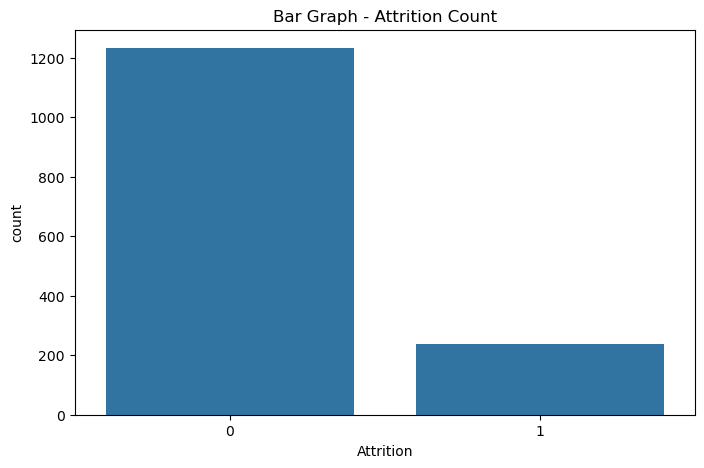

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='Attrition', data=df)
plt.title("Bar Graph - Attrition Count")
plt.show()

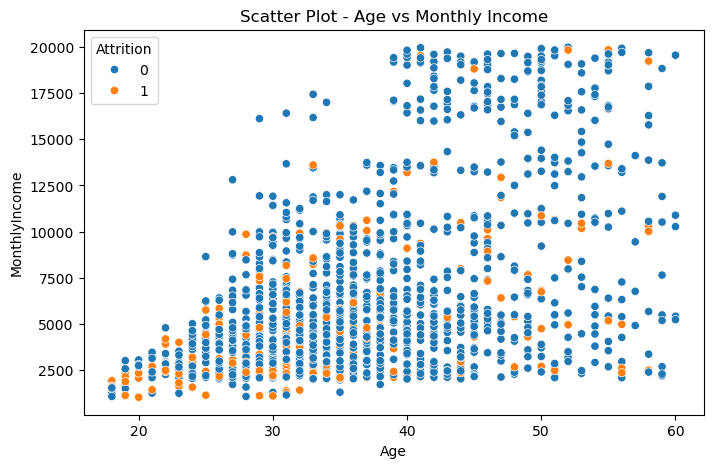

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df)
plt.title("Scatter Plot - Age vs Monthly Income")
plt.show()

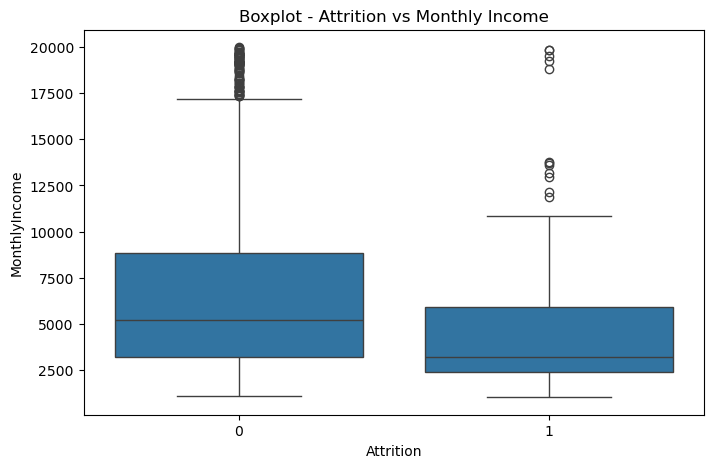

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Boxplot - Attrition vs Monthly Income")
plt.show()

In [19]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("\nInput Shape:", X.shape)
print("Target Shape:", y.shape)


Input Shape: (1470, 34)
Target Shape: (1470,)


In [20]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (1176, 34)
Testing Data: (294, 34)


In [22]:
model = LogisticRegression(max_iter=1000)


In [23]:
model = LogisticRegression(max_iter=1000)


In [24]:
model.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


In [25]:
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred[:10])


Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)



Accuracy: 0.891156462585034



Confusion Matrix:
[[249   6]
 [ 26  13]]


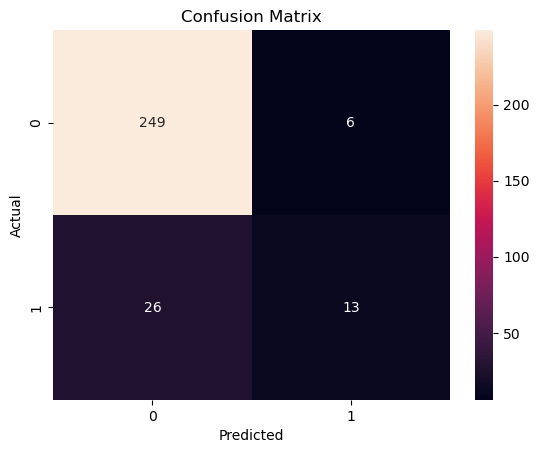

In [27]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [28]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



print("\nWeights (m values):")
print(model.coef_)

print("\nBias (c value):")
print(model.intercept_)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294


Weights (m values):
[[-0.23256936 -0.01390188 -0.08698163  0.38347709  0.27765834  0.07675492
   0.10072591  0.         -0.01992006 -0.36413233  0.19068099  0.0145733
  -0.31589736 -0.43386359 -0.13320144 -0.41137856  0.45179945 -0.18705794
   0.07751338  0.46788894  0.          0.86408458 -0.12043915  0.04007633
  -0.16184555  0.         -0.19490384 -0.3780976  -0.15878114 -0.20276817
   0.69992326 -0.67402214  0.47821057 -0.44312987]]

Bias (c value):
[-2.43366883]
